In [1]:
# # Fas 3: ML-modellering — Örebro Bostadsprisanalys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

# XGBoost
try:
    import xgboost as xgb
    print('XGBoost installerat!')
except ImportError:
    print('Kör: pip install xgboost')

# SHAP
try:
    import shap
    print('SHAP installerat!')
except ImportError:
    print('Kör: pip install shap')

print('Paket laddade!')

XGBoost installerat!
SHAP installerat!
Paket laddade!


In [2]:
## 1. Ladda och förbered data
# Ladda processad data från fas 2
df = pd.read_csv('../data/processed/orebro_housing_clean.csv')
print(f'Laddad: {len(df)} rader, {len(df.columns)} kolumner')
display(df.head())

Laddad: 6600 rader, 22 kolumner


,slutpris,avgift_kr,boarea_kvm,antal_rum,sald_datum,prisforandring_pct,pris_per_kvm,omrade,url,bostadstyp,...,sald_manad,sald_kvartal,omrade_clean,kvm_per_rum,avgift_per_kvm,avgift_andel,sasong,budkrig,prissankt,storlek_kategori
0,2700000,8768.0,117.0,4.0,2026-03-13,8.0,23077.0,Lägenhet Rynninge,https://www.hemnet.se/salda/lagenhet-4rum-rynn...,lagenheter,...,3,1,Rynninge,29.2,74.9,3.90,vår,1,0,xl (100-150)
1,1670000,5490.0,84.0,3.0,2026-03-11,1.0,19881.0,Lägenhet Hovsta,https://www.hemnet.se/salda/lagenhet-3rum-hovs...,lagenheter,...,3,1,Hovsta,28.0,65.4,3.94,vår,1,0,stor (80-100)
2,1795000,2790.0,44.0,1.0,2026-03-11,-10.0,40795.0,Lägenhet Centralt Öster,https://www.hemnet.se/salda/lagenhet-1rum-cent...,lagenheter,...,3,1,Centralt Öster,44.0,63.4,1.87,vår,0,1,liten (40-60)
3,1380000,4906.0,53.0,2.0,2026-03-11,-1.0,26038.0,B Lägenhet Sörby,https://www.hemnet.se/salda/lagenhet-2rum-sorb...,lagenheter,...,3,1,Lägenhet Sörby,26.5,92.6,4.27,vår,0,1,liten (40-60)
4,1000000,4603.0,78.5,3.0,2026-03-11,-9.0,12739.0,Lägenhet Lundby,https://www.hemnet.se/salda/lagenhet-3rum-lund...,lagenheter,...,3,1,Lundby,26.2,58.6,5.52,vår,0,1,medel (60-80)


In [3]:
# Välj features för modellen
# Vi använder numeriska + one-hot-encodade kategoriska features

numeric_features = [
    'boarea_kvm',       # Storlek
    'antal_rum',         # Antal rum
    'avgift_kr',         # Månadsavgift
    'prisforandring_pct', # Budkrig-signal
    'sald_ar',           # Vilket år
    'sald_manad',        # Vilken månad
]

categorical_features = [
    'bostadstyp',        # Lägenhet/villa/radhus
]

target = 'slutpris'

# Ta bort rader med saknade värden i våra features
model_df = df[numeric_features + categorical_features + [target]].dropna()
print(f'Rader för modellering: {len(model_df)} (av {len(df)})')

# One-hot encoding för bostadstyp
model_df = pd.get_dummies(model_df, columns=categorical_features, drop_first=True)

print(f'Features efter encoding: {model_df.shape[1] - 1}')
print(f'\nKolumner:')
print([c for c in model_df.columns if c != target])

Rader för modellering: 6097 (av 6600)
Features efter encoding: 8

Kolumner:
['boarea_kvm', 'antal_rum', 'avgift_kr', 'prisforandring_pct', 'sald_ar', 'sald_manad', 'bostadstyp_radhus', 'bostadstyp_villor']


In [4]:
# Dela upp i features (X) och målvariabel (y)
X = model_df.drop(target, axis=1)
y = model_df[target]

# Dela upp i träning (80%) och test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Träningsdata: {X_train.shape[0]} rader')
print(f'Testdata:     {X_test.shape[0]} rader')
print(f'Features:     {X_train.shape[1]}')
print(f'\nMålvariabel (slutpris):')
print(f'  Median: {y_train.median():,.0f} kr')
print(f'  Mean:   {y_train.mean():,.0f} kr')

Träningsdata: 4877 rader
Testdata:     1220 rader
Features:     8

Målvariabel (slutpris):
  Median: 2,375,000 kr
  Mean:   2,763,358 kr


In [5]:
# Skala features för linjära modeller
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Features skalade!')

Features skalade!


In [22]:
# Lägg till område som feature
# Ta de 15 vanligaste områdena, resten blir "övrigt"
top_areas = df['omrade_clean'].value_counts().head(15).index.tolist()
df['omrade_grupp'] = df['omrade_clean'].apply(lambda x: x if x in top_areas else 'övrigt')

print(f'Områdesgrupper: {df["omrade_grupp"].nunique()}')
print(df['omrade_grupp'].value_counts())

# Uppdatera features
numeric_features = [
    'boarea_kvm', 'antal_rum', 'avgift_kr',
    'prisforandring_pct', 'sald_ar', 'sald_manad',
]

categorical_features = ['bostadstyp', 'omrade_grupp']
target = 'slutpris'

model_df = df[numeric_features + categorical_features + [target]].dropna()
model_df = pd.get_dummies(model_df, columns=categorical_features, drop_first=True)

X = model_df.drop(target, axis=1)
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nFeatures: {X.shape[1]}')
print(f'Träning: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Områdesgrupper: 16
omrade_grupp
övrigt           4185
Örebro            332
Adolfsberg        325
Almby             277
Sörbyängen        244
Hovsta            157
Mellringe         152
Lundby            146
Sörby             121
Solhaga           113
Nya Hjärsta       106
Glanshammar        97
Lillån             90
Öster              87
Stora Mellösa      86
Vintrosa           82
Name: count, dtype: int64

Features: 23
Träning: 4877, Test: 1220


In [23]:
## 2. Träna modeller
# Funktion för att utvärdera en modell
def evaluate_model(name, y_true, y_pred):
    """Beräkna och visa utvärderingsmetrik."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  MAE:  {mae:>12,.0f} kr  (genomsnittligt fel)')
    print(f'  RMSE: {rmse:>12,.0f} kr  (straffar stora fel mer)')
    print(f'  R²:   {r2:>12.4f}      (1.0 = perfekt)')
    print(f'  MAPE: {mape:>12.1f}%     (procentuellt fel)')
    
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

results = []  # Samla alla resultat

In [24]:
# --- MODELL 1: Linear Regression (baseline) ---
print('Tränar Linear Regression...')
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

results.append(evaluate_model('Linear Regression', y_test, y_pred_lr))

Tränar Linear Regression...

  Linear Regression
  MAE:       624,126 kr  (genomsnittligt fel)
  RMSE:      934,477 kr  (straffar stora fel mer)
  R²:         0.6767      (1.0 = perfekt)
  MAPE:         26.3%     (procentuellt fel)


In [25]:
# --- MODELL 2: Ridge Regression ---
print('Tränar Ridge Regression...')
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

results.append(evaluate_model('Ridge Regression', y_test, y_pred_ridge))

Tränar Ridge Regression...

  Ridge Regression
  MAE:       624,124 kr  (genomsnittligt fel)
  RMSE:      934,511 kr  (straffar stora fel mer)
  R²:         0.6767      (1.0 = perfekt)
  MAPE:         26.3%     (procentuellt fel)


In [26]:
# --- MODELL 3: Random Forest ---
print('Tränar Random Forest (tar ~10-30 sek)...')
rf = RandomForestRegressor(
    n_estimators=200,      # 200 träd
    max_depth=15,           # Max djup per träd
    min_samples_split=5,    # Minst 5 samples för att dela
    min_samples_leaf=2,     # Minst 2 samples i varje löv
    random_state=42,
    n_jobs=-1               # Använd alla CPU-kärnor
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results.append(evaluate_model('Random Forest', y_test, y_pred_rf))

Tränar Random Forest (tar ~10-30 sek)...

  Random Forest
  MAE:       561,531 kr  (genomsnittligt fel)
  RMSE:      914,964 kr  (straffar stora fel mer)
  R²:         0.6901      (1.0 = perfekt)
  MAPE:         22.4%     (procentuellt fel)


In [27]:
# --- MODELL 4: XGBoost ---
print('Tränar XGBoost (tar ~10-30 sek)...')
xgb_model = xgb.XGBRegressor(
    n_estimators=300,       # 300 träd
    max_depth=8,            # Max djup
    learning_rate=0.05,     # Lärningshastighet
    subsample=0.8,          # 80% av data per träd
    colsample_bytree=0.8,   # 80% av features per träd
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

results.append(evaluate_model('XGBoost', y_test, y_pred_xgb))

Tränar XGBoost (tar ~10-30 sek)...

  XGBoost
  MAE:       546,903 kr  (genomsnittligt fel)
  RMSE:      909,783 kr  (straffar stora fel mer)
  R²:         0.6936      (1.0 = perfekt)
  MAPE:         21.5%     (procentuellt fel)


In [28]:
## 3. Jämför modeller
# Sammanställ resultat
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False)

print('\n' + '='*60)
print('  MODELL-JÄMFÖRELSE — sorterad efter R²')
print('='*60)
display(results_df[['name', 'MAE', 'RMSE', 'R2', 'MAPE']].style.format({
    'MAE': '{:,.0f} kr',
    'RMSE': '{:,.0f} kr', 
    'R2': '{:.4f}',
    'MAPE': '{:.1f}%'
}))

best = results_df.iloc[0]
print(f'\n🏆 Bästa modell: {best["name"]} (R² = {best["R2"]:.4f})')


  MODELL-JÄMFÖRELSE — sorterad efter R²


,name,MAE,RMSE,R2,MAPE
3,XGBoost,"546,903 kr","909,783 kr",0.6936,21.5%
2,Random Forest,"561,531 kr","914,964 kr",0.6901,22.4%
0,Linear Regression,"624,126 kr","934,477 kr",0.6767,26.3%
1,Ridge Regression,"624,124 kr","934,511 kr",0.6767,26.3%



🏆 Bästa modell: XGBoost (R² = 0.6936)


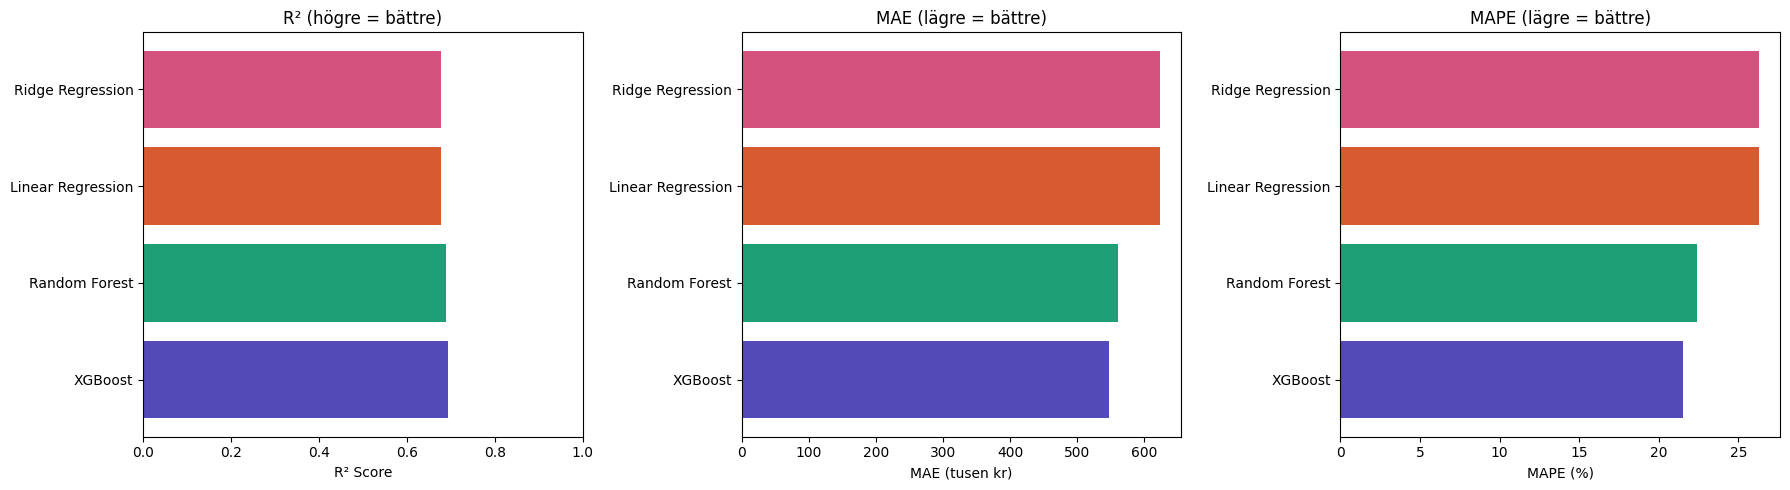

In [29]:
# Visualisera jämförelse
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#534AB7', '#1D9E75', '#D85A30', '#D4537E']

# R² (högre = bättre)
axes[0].barh(results_df['name'], results_df['R2'], color=colors[:len(results_df)])
axes[0].set_xlabel('R² Score')
axes[0].set_title('R² (högre = bättre)')
axes[0].set_xlim(0, 1)

# MAE (lägre = bättre)
axes[1].barh(results_df['name'], results_df['MAE'] / 1000, color=colors[:len(results_df)])
axes[1].set_xlabel('MAE (tusen kr)')
axes[1].set_title('MAE (lägre = bättre)')

# MAPE (lägre = bättre)
axes[2].barh(results_df['name'], results_df['MAPE'], color=colors[:len(results_df)])
axes[2].set_xlabel('MAPE (%)')
axes[2].set_title('MAPE (lägre = bättre)')

plt.tight_layout()
plt.show()

In [30]:
# Cross-validation för bästa modellen
print('Cross-validation (5-fold) för Random Forest och XGBoost...\n')

cv_rf = cross_val_score(rf, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'Random Forest  CV R²: {cv_rf.mean():.4f} (±{cv_rf.std():.4f})')

cv_xgb = cross_val_score(xgb_model, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'XGBoost        CV R²: {cv_xgb.mean():.4f} (±{cv_xgb.std():.4f})')

print(f'\n(±-värdet visar stabilitet — lägre = mer stabilt)')

Cross-validation (5-fold) för Random Forest och XGBoost...

Random Forest  CV R²: 0.3484 (±0.2889)
XGBoost        CV R²: 0.4137 (±0.1774)

(±-värdet visar stabilitet — lägre = mer stabilt)


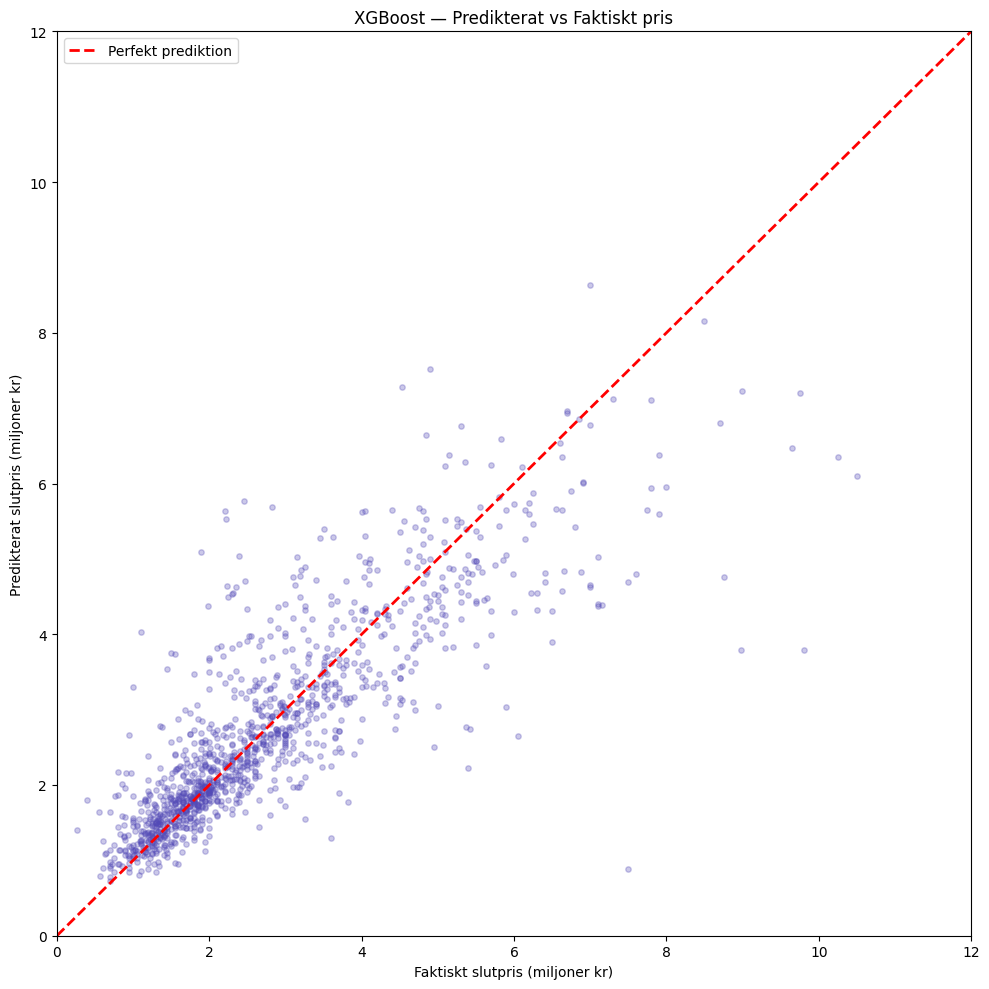

Punkter nära den röda linjen = bra prediktion
Punkter långt från linjen = modellen missade


In [31]:
# Predicted vs Actual — bästa modellen
# Avgör vilken som var bäst
if results_df.iloc[0]['name'] == 'XGBoost':
    best_pred = y_pred_xgb
    best_name = 'XGBoost'
else:
    best_pred = y_pred_rf
    best_name = 'Random Forest'

fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(y_test / 1e6, best_pred / 1e6, alpha=0.3, s=15, color='#534AB7')
ax.plot([0, 15], [0, 15], 'r--', linewidth=2, label='Perfekt prediktion')

ax.set_xlabel('Faktiskt slutpris (miljoner kr)')
ax.set_ylabel('Predikterat slutpris (miljoner kr)')
ax.set_title(f'{best_name} — Predikterat vs Faktiskt pris')
ax.legend()
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)

plt.tight_layout()
plt.show()

print('Punkter nära den röda linjen = bra prediktion')
print('Punkter långt från linjen = modellen missade')

In [32]:
## 4. SHAP-analys — Vad driver priset?
# SHAP förklarar VARFÖR modellen ger ett visst pris
# Det visar vilka features som var viktigast för varje prediktion

print('Beräknar SHAP-värden (tar ~30-60 sek)...')

# Använd bästa tree-modellen
if best_name == 'XGBoost':
    explainer = shap.TreeExplainer(xgb_model)
else:
    explainer = shap.TreeExplainer(rf)

# Beräkna SHAP på ett urval (snabbare)
X_sample = X_test.sample(min(500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

print('SHAP-värden beräknade!')

Beräknar SHAP-värden (tar ~30-60 sek)...
SHAP-värden beräknade!


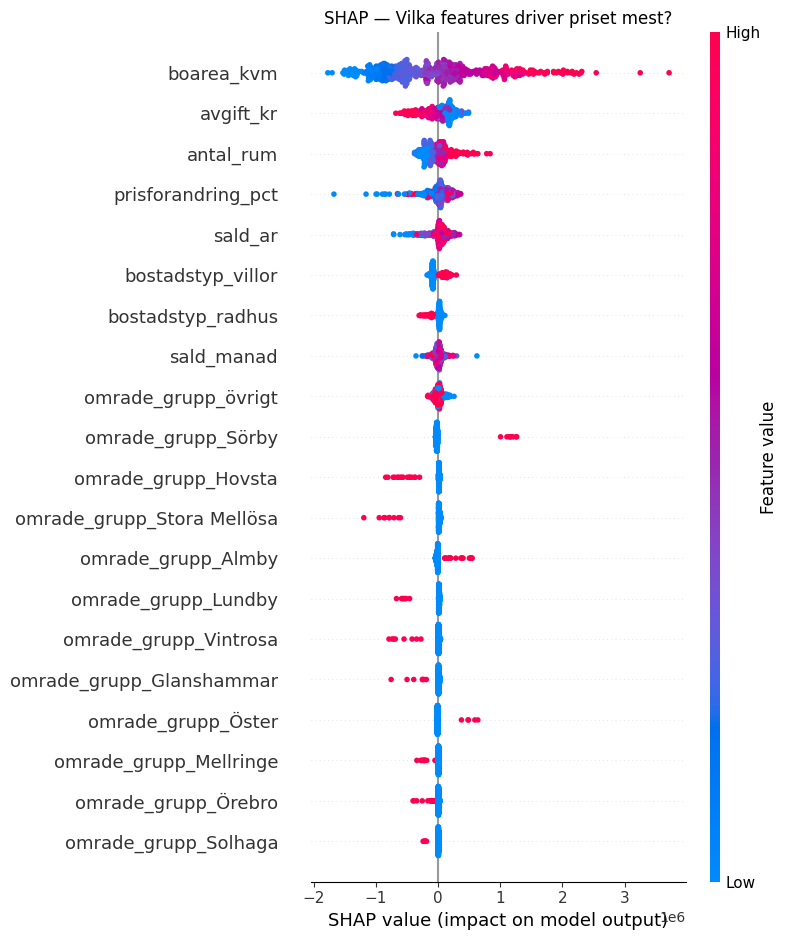

Tolkning:
  Röda prickar = högt värde på featuren
  Blåa prickar = lågt värde på featuren
  Höger = pushar priset UPP
  Vänster = pushar priset NER


In [33]:
# SHAP Summary Plot — vilka features är viktigast?
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP — Vilka features driver priset mest?')
plt.tight_layout()
plt.show()

print('Tolkning:')
print('  Röda prickar = högt värde på featuren')
print('  Blåa prickar = lågt värde på featuren')
print('  Höger = pushar priset UPP')
print('  Vänster = pushar priset NER')

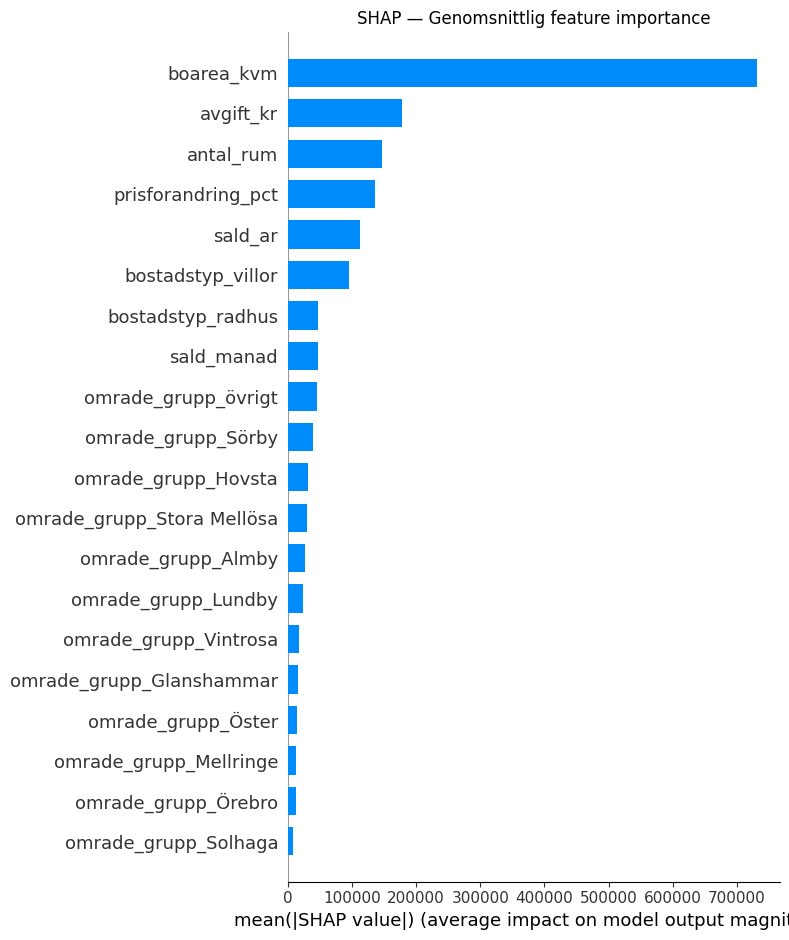

In [34]:
# SHAP Bar Plot — genomsnittlig feature importance
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('SHAP — Genomsnittlig feature importance')
plt.tight_layout()
plt.show()

In [37]:
## 5. Fynd-detektor — Hitta undervärderade bostäder
# Prediktera estimerat värde för ALLA bostäder
# Jämför med faktiskt slutpris

df_deals = model_df.copy()

if best_name == 'XGBoost':
    df_deals['estimerat_varde'] = xgb_model.predict(X)
else:
    df_deals['estimerat_varde'] = rf.predict(X)

df_deals['avvikelse_kr'] = df_deals['estimerat_varde'] - df_deals['slutpris']
df_deals['avvikelse_pct'] = (
    (df_deals['estimerat_varde'] - df_deals['slutpris']) / df_deals['estimerat_varde'] * 100
).round(1)

# Fynd = såldes för MINDRE än modellen säger att den är värd
threshold = 15  # Minst 15% undervärderad
deals = df_deals[df_deals['avvikelse_pct'] >= threshold].sort_values('avvikelse_pct', ascending=False)

print(f'Potentiella fynd (>{threshold}% undervärderade): {len(deals)} bostäder')
print(f'\nTopp 10 fynd:')
display(deals[['slutpris', 'estimerat_varde', 'avvikelse_pct', 'boarea_kvm', 'antal_rum', 'bostadstyp_radhus', 'bostadstyp_villor']].head(10))

Potentiella fynd (>15% undervärderade): 909 bostäder

Topp 10 fynd:


,slutpris,estimerat_varde,avvikelse_pct,boarea_kvm,antal_rum,bostadstyp_radhus,bostadstyp_villor
93,265000,1406071.000,81.2,65.0,2.0,False,False
3634,745000,3427126.500,78.3,120.0,4.0,False,True
684,400000,1797810.500,77.8,76.3,3.0,False,False
4962,1100000,4031758.500,72.7,130.0,6.0,False,True
4355,450000,1624627.250,72.3,73.0,4.0,False,True
3578,820000,2887195.250,71.6,98.0,4.0,False,True
4903,455000,1554269.875,70.7,115.0,5.0,False,True
4456,500000,1682906.500,70.3,75.0,3.0,False,True
3571,1000000,3296556.500,69.7,103.0,5.0,False,True
2655,550000,1640831.625,66.5,50.0,2.0,False,True


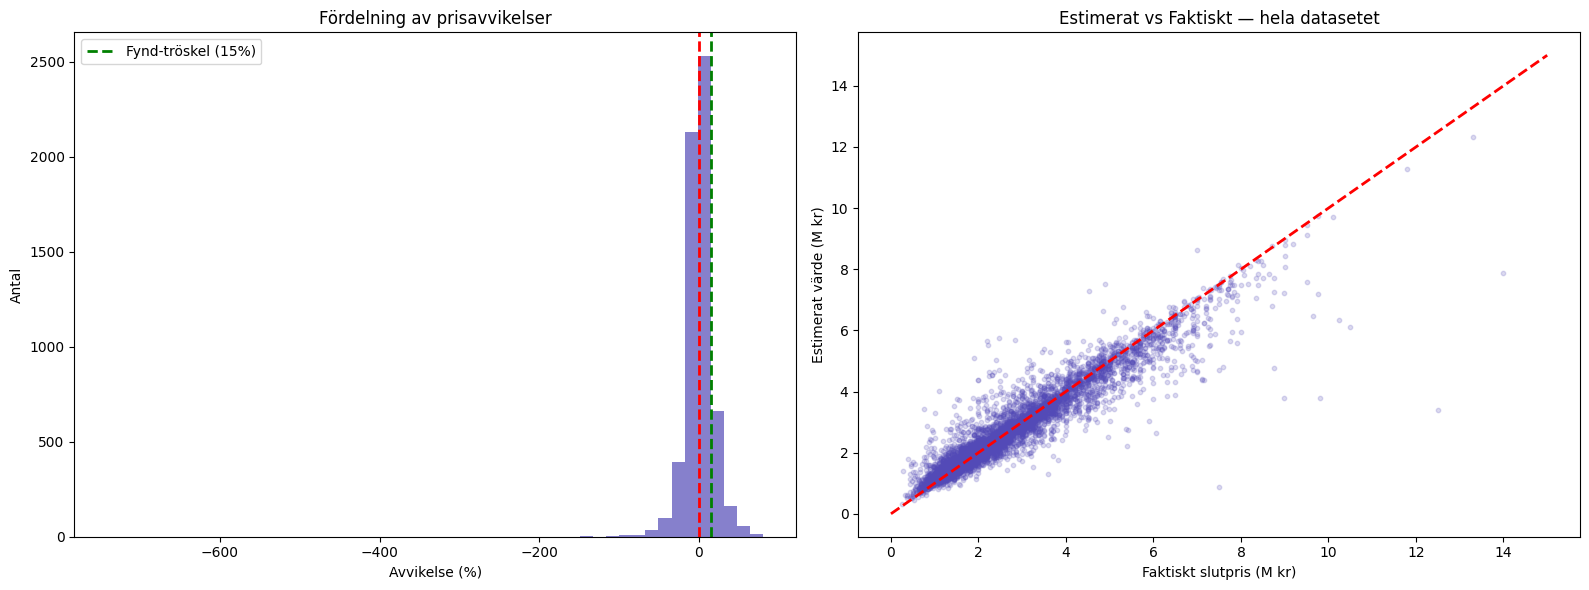

In [38]:
# Visualisera avvikelser
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram av avvikelser
ax1.hist(df_deals['avvikelse_pct'], bins=50, color='#534AB7', alpha=0.7)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax1.axvline(x=threshold, color='green', linestyle='--', linewidth=2, label=f'Fynd-tröskel ({threshold}%)')
ax1.set_xlabel('Avvikelse (%)')
ax1.set_ylabel('Antal')
ax1.set_title('Fördelning av prisavvikelser')
ax1.legend()

# Scatter: estimerat vs faktiskt
ax2.scatter(df_deals['slutpris']/1e6, df_deals['estimerat_varde']/1e6, alpha=0.2, s=10, color='#534AB7')
ax2.plot([0, 15], [0, 15], 'r--', linewidth=2)
ax2.set_xlabel('Faktiskt slutpris (M kr)')
ax2.set_ylabel('Estimerat värde (M kr)')
ax2.set_title('Estimerat vs Faktiskt — hela datasetet')

plt.tight_layout()
plt.show()

In [39]:
## 6. Spara modellen
import os
os.makedirs('../models', exist_ok=True)

# Spara bästa modellen
model_data = {
    'model': xgb_model if best_name == 'XGBoost' else rf,
    'model_name': best_name,
    'scaler': scaler,
    'feature_names': list(X.columns),
    'results': results_df.to_dict(),
    'metrics': {
        'R2': float(results_df.iloc[0]['R2']),
        'MAE': float(results_df.iloc[0]['MAE']),
        'MAPE': float(results_df.iloc[0]['MAPE']),
    }
}

joblib.dump(model_data, '../models/best_model.pkl')
print(f'Modell sparad: ../models/best_model.pkl')
print(f'Modell: {best_name}')
print(f'R²: {model_data["metrics"]["R2"]:.4f}')
print(f'MAE: {model_data["metrics"]["MAE"]:,.0f} kr')

print(f'\n=== FAS 3 KLAR ===')
print(f'Nästa steg: Streamlit dashboard (fas 4)')

Modell sparad: ../models/best_model.pkl
Modell: XGBoost
R²: 0.6936
MAE: 546,903 kr

=== FAS 3 KLAR ===
Nästa steg: Streamlit dashboard (fas 4)
